License

- Content (explanatory text, figures): CC BY 4.0 — see /LICENSE-CONTENT
- Code cells and standalone code files: MIT License — see /LICENSE-CODE

Attribution example: Getman, R. (2026). CBE 3610 Python Notebooks and Course Materials. https://github.com/dr-rachel-bg-teaching/CBE3610


# Example context:

This is the same example as we solved for a CSTR; now we are solving it in a PFR.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Given Data

In [ ]:
C0 = np.array([0.2, 0.0, 0.0, 0.0, 0.0])  # [CA0, CB0, CC0, CD0, CE0], mol/L
v0 = 100                                  # L/min
V_max = 400                               # L
F0 = v0 * C0
CT0 = np.sum(C0)

## Construct species rates and stoichiometry matrix

In [ ]:
rate_constants = (7, 3, 2)  # (k1A, k2D, k3E) # units: min^-1, L^2/mol^2/min, L/mol/min
nu = np.array([[-1, 1/3, 1/3, 0, 0],
               [-1/3, 0, -2/3, 1, 0],
               [0, 0, -1, -4/3, 1]])

## mole balances

In [ ]:
def PFR(V, F, nu, CT0, rate_constants):
  FT = np.sum(F)
  C = CT0 * (F / FT)

  # Reaction rates
  r = np.array([
      rate_constants[0] * C[0],
      rate_constants[1] * (C[2]**2) * C[0],
      rate_constants[2] * C[3] * C[2]
  ])

  # Species rates
  return np.dot(nu.T, r)

## solve and plot

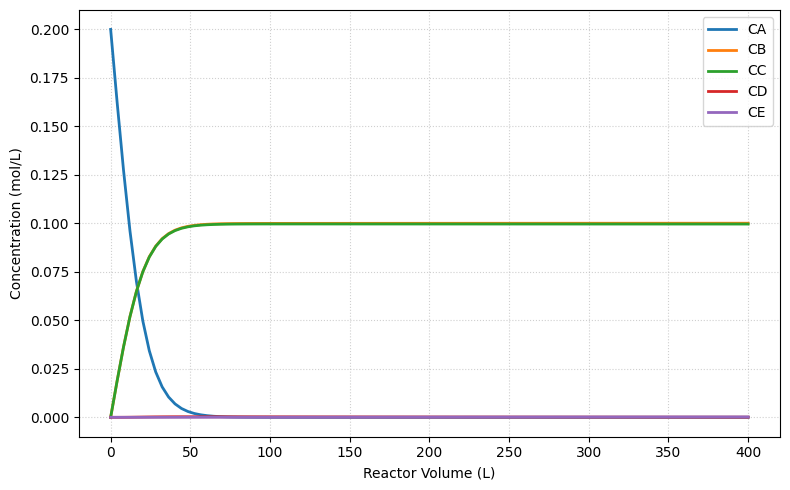

In [ ]:
pfr_vol = np.linspace(0, V_max, 100)
sol = solve_ivp(PFR, t_span=(0, V_max), y0=F0, t_eval=pfr_vol, args=(nu, CT0, rate_constants))

FT_profile = np.sum(sol.y, axis=0) # total molar flowrate at each volume step
C_profile = CT0 * (sol.y / FT_profile)

plt.figure(figsize=(8, 5))
labels = ["CA", "CB", "CC", "CD", "CE"]
for i in range(5):
    plt.plot(sol.t, C_profile[i], label=labels[i], lw=2)

plt.xlabel("Reactor Volume (L)")
plt.ylabel("Concentration (mol/L)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()